# CSCIE89 - Basic CNN in PyTorch (Problem 1: MNIST via torchvision)

In this notebook, we will build a **basic convolutional neural network (CNN)** that recognizes handwritten digits from 0 to 9. This is the homework version of the class notebook (`1_pytorch_basic_cnn_digits.ipynb`): instead of the small `digits` image dataset that comes with scikit-learn (8 x 8 images), we use the **MNIST dataset from `torchvision`**, where each image is **28 x 28**.

Our Objectives:

1. Load and inspect image data.
2. Divide data into training, validation, and test sets.
3. convert NumPy arrays into PyTorch tensors and data loaders.
4. Define a small, vanilla CNN.
5. Train the model while tracking loss and accuracy.
6. Evaluate it on data it has never seen.
7. Visualize learning curves, a confusion matrix, and predictions.
8. Run inference on a few images of our own handwriting.

> **Why do we have Train/test/valid?** The training set teaches the model. The validation set helps us observe learning without touching the final test set ( think unit testiong) . The test set gives an unbiased final estimate of performance ( this is dataset in your managers drawer).

## 1. Setup and imports

If an import fails, make sure you have all right packages installed. Ask for help on Ed dicussions or email the cscie89 teaching staff

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from torchvision import datasets

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)

# Random processes are used when splitting and shuffling data and when
# initializing model weights. A fixed seed makes results more repeatable.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Apple Silicon use MPS; laptops with NVIDIA GPUs can use CUDA.
# This dataset also trains quickly on a CPU. So dont worry
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Using device: {device}")


PyTorch version: 2.14.0+cu130
Using device: cpu


## 2. Load and explore the images

Each example is a 28 x 28 grayscale image from the **MNIST** dataset (loaded via `torchvision.datasets.MNIST`, downloaded automatically the first time this cell runs). Pixel values range from 0 (dark) to 255 (bright), and the target is the digit shown in the image.

Images shape: (70000, 28, 28)
Labels shape: (70000,)


Pixel range: 0 to 255
Classes: [0 1 2 3 4 5 6 7 8 9]


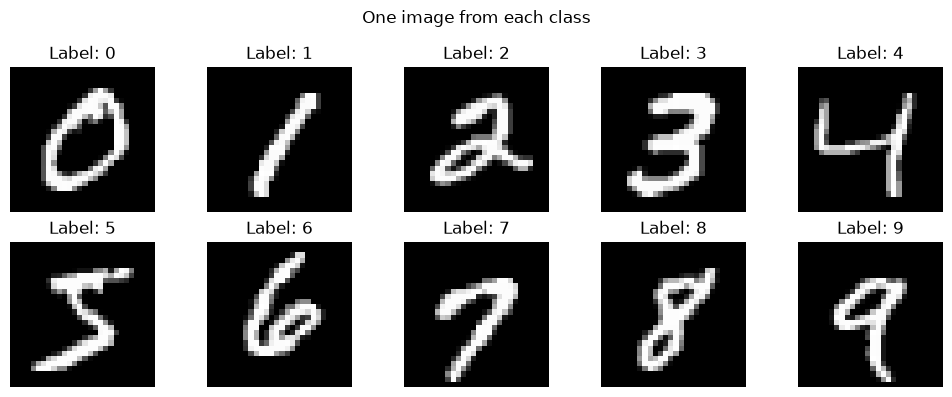

In [2]:
mnist_train = datasets.MNIST(root="./data", train=True, download=True)
mnist_test = datasets.MNIST(root="./data", train=False, download=True)

# Combine train + test into one pool of images/labels, the same way the
# small sklearn `digits` dataset was one pool that we split ourselves below.
images = torch.cat([mnist_train.data, mnist_test.data]).numpy()   # Shape: (70000, 28, 28)
labels = torch.cat([mnist_train.targets, mnist_test.targets]).numpy()
class_names = np.arange(10)

print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Pixel range: {images.min()} to {images.max()}")
print(f"Classes: {class_names}")

# Display one example from each class.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for digit, ax in enumerate(axes.flat):
    example_index = np.where(labels == digit)[0][0]
    ax.imshow(images[example_index], cmap="gray")
    ax.set_title(f"Label: {digit}")
    ax.axis("off")
plt.suptitle("One image from each class")
plt.tight_layout()
plt.show()


## 3. Create training, validation, and test datasets

We use 70% of the images for training, 15% for validation, and 15% for testing. `stratify=labels` keeps roughly the same proportion of each digit in every split.

We also divide every pixel by 255, changing the range from 0-255 to 0-1. Neural networks generally train more smoothly with small, consistently scaled inputs.

In [3]:
# First reserve 30% for validation + testing reaming 70% for training.
X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels, test_size=0.30, random_state=SEED, stratify=labels
)

# Split that remaining 30% evenly: 15% validation and 15% test.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

def make_image_tensor(array):
    """Convert images to float tensors with CNN shape (N, C, H, W).

    N = number of images, C = channels, H = height, W = width.
    Grayscale images have one channel, so unsqueeze(1) adds C = 1.
    """
    return torch.tensor(array, dtype=torch.float32).unsqueeze(1) / 255.0

X_train_t = make_image_tensor(X_train)
X_val_t = make_image_tensor(X_val)
X_test_t = make_image_tensor(X_test)

# CrossEntropyLoss expects class labels to be 64-bit integers (torch.long).
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print(f"Training:   {len(X_train_t):5d} images ({len(X_train_t)/len(images):.0%})")
print(f"Validation: {len(X_val_t):5d} images ({len(X_val_t)/len(images):.0%})")
print(f"Test:       {len(X_test_t):5d} images ({len(X_test_t)/len(images):.0%})")
print(f"One CNN batch will have shape (batch, channel, height, width).")
print(f"One image tensor has shape: {X_train_t[0].shape}")


Training:   49000 images (70%)
Validation: 10500 images (15%)
Test:       10500 images (15%)
One CNN batch will have shape (batch, channel, height, width).
One image tensor has shape: torch.Size([1, 28, 28])


## 4. Put the data into DataLoaders

We will use  `TensorDataset` that pairs every image with its label. And also `DataLoader` which serves small batches to the model. Training data is shuffled each epoch so the model does not learn from a fixed ordering. Validation and test data do not need shuffling.

`train_generator` creates a random-number generator with a fixed starting point. in our case it controls how the DataLoader shuffles the training images


In [4]:
BATCH_SIZE = 64

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# The generator makes the shuffled training order reproducible.
train_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=train_generator
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch_images, batch_labels = next(iter(train_loader))
print(f"Image batch shape: {batch_images.shape}")
print(f"Label batch shape: {batch_labels.shape}")


Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


## 5. Define a vanilla CNN

The network has two conceptual parts:

- **Feature extractor:** convolution layers slide small filters across the image. ReLU adds non-linearity, and max pooling reduces width and height.
- **Classifier:** the feature maps are flattened into a vector and passed to a linear layer that produces 10 class scores, called **logits**.

Shape changes: `(1, 28, 28) → (8, 28, 28) → (8, 14, 14) → (16, 14, 14) → (16, 7, 7) → 784 → 10`.

In [5]:
class BasicCNN(nn.Module):
    """A small CNN for 28 x 28, one-channel images."""

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Padding=1 keeps height and width at 28 x 28.
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1),
            nn.ReLU(),
            # Pooling changes 28 x 28 into 14 x 14.
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            # Pooling changes 14 x 14 into 7 x 7.
            nn.MaxPool2d(kernel_size=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                    # 16 feature maps x 7 x 7 = 784 values
            nn.Linear(16 * 7 * 7, 32),
            nn.ReLU(),
            nn.Linear(32, 10),              # One score for each digit
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = BasicCNN().to(device)
print(model)

# Confirm that a batch produces one row of 10 scores per image.
with torch.no_grad():
    example_output = model(batch_images.to(device))
print(f"Model output shape: {example_output.shape}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


BasicCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)
Model output shape: torch.Size([64, 10])
Trainable parameters: 26,698


## 6. Loss, optimizer, and evaluation function

`CrossEntropyLoss` compares the 10 raw class scores with the correct class. It already performs the softmax-related mathematics internally, so we **do not add a softmax layer** to the model.

The Adam optimizer updates weights to reduce loss. During evaluation, `model.eval()` turns off training-only behavior, and `torch.no_grad()` avoids storing gradients, saving memory.

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

def evaluate(model, data_loader, criterion, device):
    """Return average loss and accuracy without changing model weights."""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for inputs, targets in data_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            logits = model(inputs)
            loss = criterion(logits, targets)
            predictions = logits.argmax(dim=1)

            # Multiply by batch size because loss is an average for this batch.
            total_loss += loss.item() * inputs.size(0)
            total_correct += (predictions == targets).sum().item()
            total_examples += inputs.size(0)

    return total_loss / total_examples, total_correct / total_examples


## 7. Train the model

For each batch, training follows five steps:
            clear old gradients,
            make predictions,
            calculate loss,
            calculate gradients with backpropagation,
            and update the weights.

One complete pass through the training set is an **epoch**.

Logits are the raw scores the model produces for each possible class.
Logits are not probabilities: they can be negative and don't need to sum to 1.

 Digit:  0    1     2    3    4    5    6    7    8    9
 Logits:
        [0.2, -1.0, 0.5, 3.1, 0.0, 0.8, -0.4, 1.2, 0.3, 0.1]

The highest score is 3.1 at index 3, so the predicted digit is 3.

During training, pass these raw scores directly to CrossEntropyLoss, PyTorch's nn.CrossEntropyLoss already includes the probability-conversion calculation, so you give it the raw logits.

Conceptually, it does two things:
1. Converts logits into probabilities using softmax.
2. Calculates the loss from the probability assigned to the correct class

If you apply softmax first, CrossEntropyLoss treats those probabilities as raw scores and normalizes them again, changing the intended calculation.

In [7]:
EPOCHS = 12
history = {
    "train_loss": [], "train_accuracy": [],
    "val_loss": [], "val_accuracy": [],
}

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_examples = 0

    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()          # 1. Clear gradients from the previous batch.
        logits = model(inputs)         # 2. Forward pass: compute class scores.
        loss = criterion(logits, targets)  # 3. Measure prediction error.
        loss.backward()                # 4. Backward pass: compute gradients.
        optimizer.step()               # 5. Update the model's weights.

        predictions = logits.argmax(dim=1)
        running_loss += loss.item() * inputs.size(0)
        running_correct += (predictions == targets).sum().item()
        running_examples += inputs.size(0)

    train_loss = running_loss / running_examples
    train_accuracy = running_correct / running_examples
    val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train loss {train_loss:.4f}, accuracy {train_accuracy:.3f} | "
        f"val loss {val_loss:.4f}, accuracy {val_accuracy:.3f}"
    )


Epoch 01/12 | train loss 0.2624, accuracy 0.915 | val loss 0.0949, accuracy 0.972


Epoch 02/12 | train loss 0.0768, accuracy 0.976 | val loss 0.0907, accuracy 0.970


Epoch 03/12 | train loss 0.0574, accuracy 0.982 | val loss 0.0647, accuracy 0.981


Epoch 04/12 | train loss 0.0477, accuracy 0.985 | val loss 0.0609, accuracy 0.982


Epoch 05/12 | train loss 0.0411, accuracy 0.987 | val loss 0.0673, accuracy 0.981


...

Epoch 08/12 | train loss 0.0300, accuracy 0.990 | val loss 0.0600, accuracy 0.983


Epoch 09/12 | train loss 0.0283, accuracy 0.991 | val loss 0.0781, accuracy 0.979


Epoch 10/12 | train loss 0.0249, accuracy 0.992 | val loss 0.0589, accuracy 0.983


Epoch 11/12 | train loss 0.0219, accuracy 0.993 | val loss 0.0572, accuracy 0.986


Epoch 12/12 | train loss 0.0209, accuracy 0.993 | val loss 0.0648, accuracy 0.985


## 8. Plot the learning curves

Loss measures error (lower is better), while accuracy is the fraction predicted correctly (higher is better). If training keeps improving while validation gets worse, the model may be overfitting.

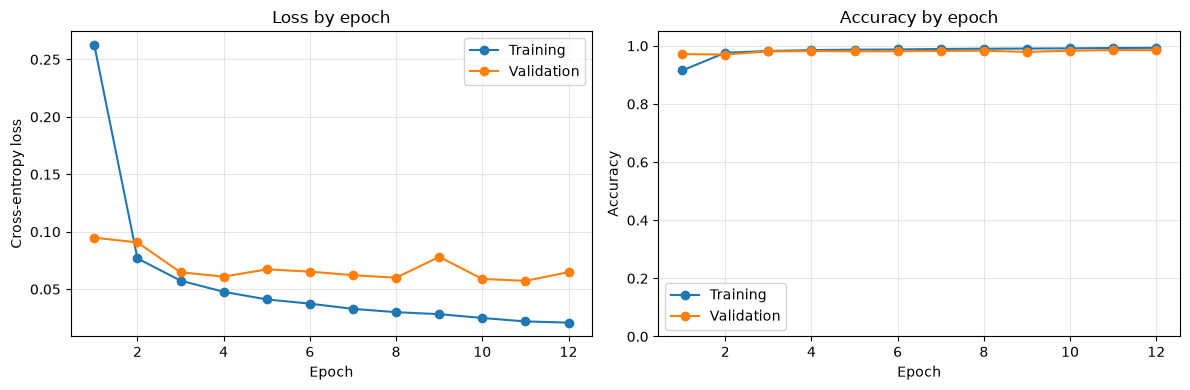

In [8]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], marker="o", label="Training")
axes[0].plot(epochs, history["val_loss"], marker="o", label="Validation")
axes[0].set(title="Loss by epoch", xlabel="Epoch", ylabel="Cross-entropy loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_accuracy"], marker="o", label="Training")
axes[1].plot(epochs, history["val_accuracy"], marker="o", label="Validation")
axes[1].set(title="Accuracy by epoch", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1.05))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Final evaluation on the untouched test set

We use the test set only after training is finished. Besides overall loss and accuracy, the classification report shows precision, recall, and F1-score for every digit. The confusion matrix shows which digits are confused with one another.

Test loss:     0.0566
Test accuracy: 98.52%


Accuracy check with scikit-learn: 98.52%

Classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1035
           1       0.99      0.99      0.99      1181
           2       0.99      0.98      0.98      1049
           3       0.99      0.98      0.99      1071
           4       0.99      0.99      0.99      1024
           5       0.99      0.98      0.99       947
           6       0.99      0.99      0.99      1032
           7       0.97      0.99      0.98      1094
           8       0.98      0.98      0.98      1024
           9       0.97      0.98      0.98      1043

    accuracy                           0.99     10500
   macro avg       0.99      0.99      0.99     10500
weighted avg       0.99      0.99      0.99     10500



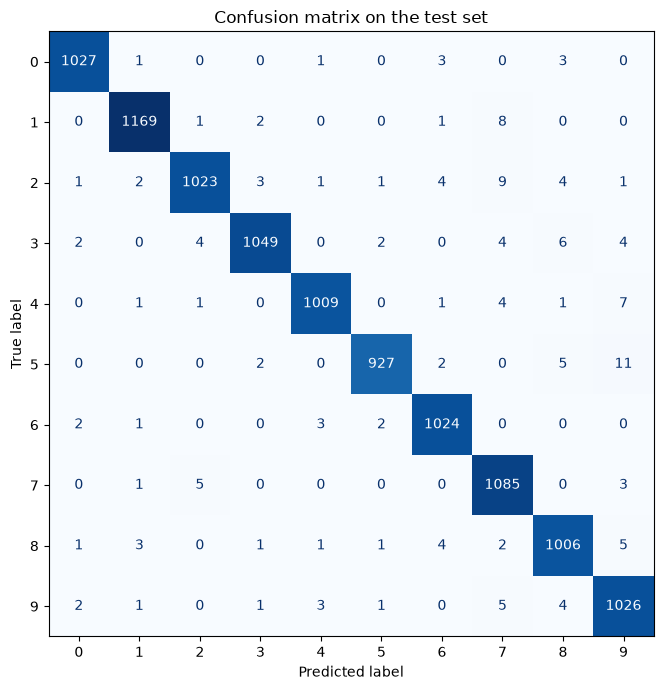

In [9]:
test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

# Collect every test prediction on the CPU for scikit-learn metrics.
model.eval()
all_predictions = []
all_targets = []
with torch.no_grad():
    for inputs, targets in test_loader:
        logits = model(inputs.to(device))
        predictions = logits.argmax(dim=1).cpu()
        all_predictions.extend(predictions.numpy())
        all_targets.extend(targets.numpy())

print(f"Accuracy check with scikit-learn: {accuracy_score(all_targets, all_predictions):.2%}")
print("\nClassification report:")
print(classification_report(all_targets, all_predictions, target_names=[str(x) for x in class_names]))

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    all_targets, all_predictions, display_labels=class_names, cmap="Blues", ax=ax, colorbar=False
)
ax.set_title("Confusion matrix on the test set")
plt.tight_layout()
plt.show()


### How to read the metrics

- **Accuracy:** proportion of all predictions that were correct.
- **Precision for a digit:** when the model predicts this digit, how often is it correct?
- **Recall for a digit:** of all real examples of this digit, how many did the model find?
- **F1-score:** a combined measure of precision and recall.
- **Support:** number of test examples belonging to that digit.
- **Confusion matrix:** correct predictions are on the main diagonal; off-diagonal cells are mistakes.

## 10. Look at individual predictions

A metric summarizes performance, but seeing individual examples makes the result more concrete. Green titles are correct predictions and red titles are mistakes.

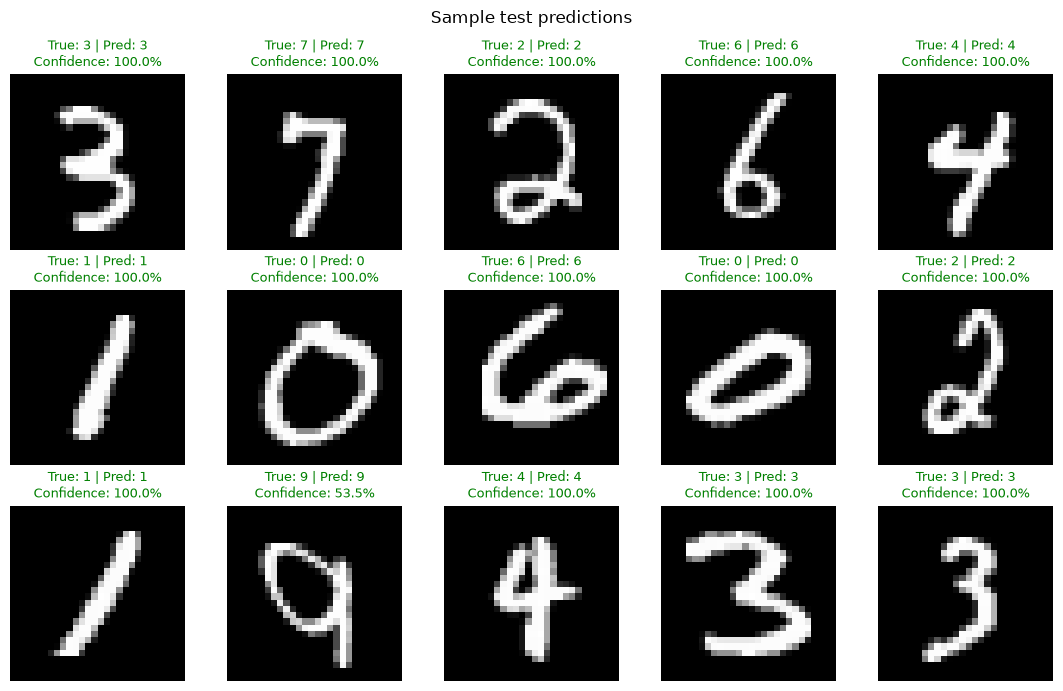

In [10]:
# Use a fixed random generator so the displayed sample is repeatable.
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(len(X_test_t), size=15, replace=False)

model.eval()
with torch.no_grad():
    sample_logits = model(X_test_t[sample_indices].to(device))
    sample_probabilities = torch.softmax(sample_logits, dim=1).cpu()
    sample_predictions = sample_probabilities.argmax(dim=1)

fig, axes = plt.subplots(3, 5, figsize=(11, 7))
for ax, index, prediction, probabilities in zip(
    axes.flat, sample_indices, sample_predictions, sample_probabilities
):
    actual = int(y_test_t[index])
    predicted = int(prediction)
    confidence = float(probabilities[predicted])
    color = "green" if predicted == actual else "red"

    ax.imshow(X_test_t[index, 0], cmap="gray")
    ax.set_title(
        f"True: {actual} | Pred: {predicted}\nConfidence: {confidence:.1%}",
        color=color, fontsize=9
    )
    ax.axis("off")

plt.suptitle("Sample test predictions")
plt.tight_layout()
plt.show()


## 11. Save and reload the trained model (optional)

Saving a `state_dict` stores the learned weights. To use them later, create the same architecture and load the weights into it.

In [11]:
MODEL_PATH = "basic_cnn_mnist.pth"
torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved weights to {MODEL_PATH}")

# Example reload:
reloaded_model = BasicCNN().to(device)
reloaded_model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
reloaded_model.eval()
reloaded_loss, reloaded_accuracy = evaluate(reloaded_model, test_loader, criterion, device)
print(f"Reloaded model test accuracy: {reloaded_accuracy:.2%}")


Saved weights to basic_cnn_mnist.pth


Reloaded model test accuracy: 98.52%


## 12. Inference on your own handwriting (Problem 1)

Drop a few photos of digits you've drawn by hand into the `handwritten_digits/` folder (any image format, roughly square crops work best) and re-run this section. Each image is converted to grayscale, resized to 28 x 28, and inverted/scaled to match MNIST's white-digit-on-black-background convention (same `/255.0` scaling used in Section 3) before being fed to the trained model. This is **inference only** — the model is not retrained here.

If the folder is empty, a few simple placeholder "handwritten-style" digit images are generated on the fly with `PIL.ImageDraw` so this section still has something to run on — swap these out for your own real handwriting photos any time. Just a handful of images is enough here, per the assignment ("do not overdo this").

Running inference on 4 image(s): ['digit_1_2.png', 'digit_0_1.png', 'digit_7_4.png', 'digit_3_3.png']


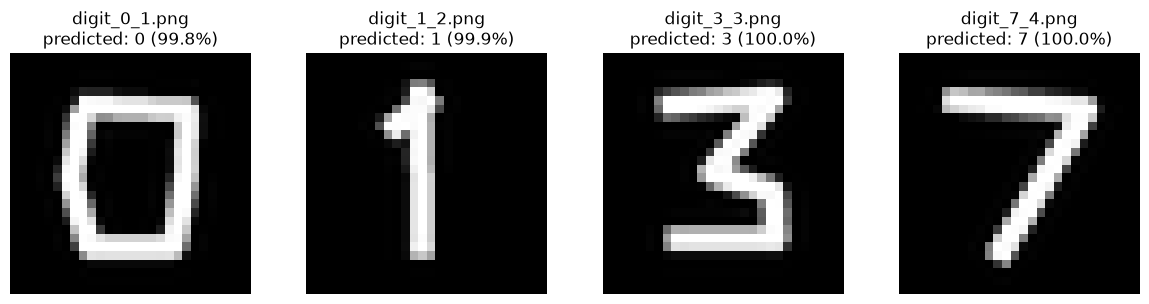

In [12]:
import os
from PIL import Image, ImageDraw

HANDWRITTEN_DIR = "handwritten_digits"
os.makedirs(HANDWRITTEN_DIR, exist_ok=True)


def _make_placeholder_digit(digit, path, size=200, seed=0):
    """Draw a simple, slightly jittered stroke-based digit as a stand-in
    for a real handwriting photo (black strokes on a white canvas)."""
    rng = random.Random(seed)
    img = Image.new("L", (size, size), color=255)
    draw = ImageDraw.Draw(img)
    jitter = lambda v: v + rng.randint(-6, 6)
    width = size // 10

    strokes = {
        0: [[(0.3, 0.2), (0.7, 0.2), (0.75, 0.5), (0.7, 0.8), (0.3, 0.8), (0.25, 0.5), (0.3, 0.2)]],
        1: [[(0.5, 0.15), (0.5, 0.85)], [(0.35, 0.3), (0.5, 0.15)]],
        3: [[(0.25, 0.2), (0.7, 0.2), (0.45, 0.48), (0.7, 0.55), (0.7, 0.8), (0.25, 0.8)]],
        7: [[(0.2, 0.2), (0.8, 0.2), (0.4, 0.85)]],
    }
    for stroke in strokes.get(digit, strokes[1]):
        pts = [(jitter(int(x * size)), jitter(int(y * size))) for x, y in stroke]
        draw.line(pts, fill=0, width=width, joint="curve")
    img.save(path)


existing = [f for f in os.listdir(HANDWRITTEN_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
if not existing:
    print("No images found in 'handwritten_digits/' -- generating a few placeholder samples.")
    placeholders = [(0, 1), (1, 2), (3, 3), (7, 4)]
    for digit, idx in placeholders:
        _make_placeholder_digit(digit, os.path.join(HANDWRITTEN_DIR, f"digit_{digit}_{idx}.png"), seed=idx)
    existing = [f for f in os.listdir(HANDWRITTEN_DIR) if f.lower().endswith((".png", ".jpg", ".jpeg"))]

print(f"Running inference on {len(existing)} image(s): {existing}")


def preprocess_handwritten(path):
    img = Image.open(path).convert("L").resize((28, 28), Image.LANCZOS)
    arr = np.array(img).astype(np.float32) / 255.0

    # If the drawing is dark strokes on a light background (typical of a
    # photo/scan), invert it so digits are white-on-black like MNIST.
    if arr.mean() > 0.5:
        arr = 1.0 - arr

    tensor = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).float()  # (1, 1, 28, 28)
    return tensor, arr


model.eval()
fig, axes = plt.subplots(1, len(existing), figsize=(3 * len(existing), 3))
if len(existing) == 1:
    axes = [axes]

for ax, fname in zip(axes, sorted(existing)):
    path = os.path.join(HANDWRITTEN_DIR, fname)
    tensor, display_arr = preprocess_handwritten(path)
    with torch.no_grad():
        probabilities = torch.softmax(model(tensor.to(device)), dim=1).cpu().squeeze(0)
        pred = int(probabilities.argmax())
        confidence = float(probabilities[pred])

    ax.imshow(display_arr, cmap="gray")
    ax.set_title(f"{fname}\npredicted: {pred} ({confidence:.1%})")
    ax.axis("off")

plt.tight_layout()
plt.show()


## Summary

Through this example we have used a CNN and seen a full image-classification workflow: data loading, splitting, preprocessing, batching, CNN construction, training, validation, final testing, metrics, visualization, and saving weights — this time on the full 28 x 28 MNIST dataset from `torchvision` instead of the tiny 8 x 8 `digits` dataset. We finished with inference-only predictions on a few images of our own handwriting.